**PREDICTIVE ANALYTICS FOR THE DIAGNOSIS OF RESPIRATORY DISEASES**

**GENERAL OBJECTIVE**

To utilize a machine leaning algorithm in developing a predictive model that performs early detection and diagnosis of respiratory disorders

**SPECIFIC OBJECTIVES**

1)To collect relevant patient data with medical records and symptoms.

2)To identify salient features in the medical data for improved prediction accuracy.

3)To evaluate the model's performance in predicting respiratory disorders using performance metrics .

4)To develop a machine learning model capable of predicting the likelihood of specific respiratory diseases based on  medical data.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

a)IMPORTING LIBRARIES These above libraries are key for data analysis in Python. Pandas- handles and manipulates data, NumPy -supports numerical operations, Seaborn -creates statistical visualizations, and Matplotlib -provides basic plotting tools.

In [3]:
data=pd.read_csv("C:/Users/david/OneDrive/Desktop/DATASETS/Exasens.csv")

This code above reads a CSV file from the specified path and loads it into a Pandas DataFrame named "data", allowing for easy data manipulation and analysis.

In [5]:
data.head()

,Diagnosis,ID,Imagery_part_min,Imagery_part_avg,Real_part_min,Real_part_avg,Gender,Age,Smoking
0,COPD,301-4,-320.61,-300.563531,-495.26,-464.171991,1,77,2
1,COPD,302-3,-325.39,-314.750360,-473.73,-469.263140,0,72,2
2,COPD,303-3,-323.00,-317.436056,-476.12,-471.897667,1,73,3
3,COPD,304-4,-327.78,-317.399670,-473.73,-468.856388,1,76,2
4,COPD,305-4,-325.39,-316.155785,-478.52,-472.869783,0,65,2


The code above displays the first five rows of the DataFrame "data"

In [7]:
data.tail()

,Diagnosis,ID,Imagery_part_min,Imagery_part_avg,Real_part_min,Real_part_avg,Gender,Age,Smoking
394,Infected,I176,NaN,NaN,NaN,NaN,0,49,2
395,Infected,I177,NaN,NaN,NaN,NaN,0,37,1
396,Infected,I178,NaN,NaN,NaN,NaN,0,29,1
397,Infected,I179,NaN,NaN,NaN,NaN,1,51,1
398,Infected,I180,NaN,NaN,NaN,NaN,0,40,1


The code above displays the last five rows of the DataFrame "data"

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Diagnosis         399 non-null    object 
 1   ID                399 non-null    object 
 2   Imagery_part_min  100 non-null    float64
 3   Imagery_part_avg  100 non-null    float64
 4   Real_part_min     100 non-null    float64
 5   Real_part_avg     100 non-null    float64
 6   Gender            399 non-null    int64  
 7   Age               399 non-null    int64  
 8   Smoking           399 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 28.2+ KB


The above "data.info() function" gives a  summary of the DataFrame, showing the number of rows and columns, column names, data types, and how many non-null (non-missing) values each column contains. It also includes memory usage.

In [11]:
data.isnull().sum()

Diagnosis             0
ID                    0
Imagery_part_min    299
Imagery_part_avg    299
Real_part_min       299
Real_part_avg       299
Gender                0
Age                   0
Smoking               0
dtype: int64

The above code is a function that  counts the number of missing (null) values in each column. The output shows that four columns—Imagery_part_min, Imagery_part_avg, Real_part_min, and Real_part_avg—each have 299 missing values, while the other columns have no missing values. 

In [13]:
for column in data.columns:
    if data[column].dtype == 'object':
        data[column].fillna(data[column].mode()[0], inplace=True)  # Fill categorical with mode
    else:
        data[column].fillna(data[column].median(), inplace=True)  # Fill numerical with median

print("\nMissing Values After Filling:")
print(data.isnull().sum())


Missing Values After Filling:
Diagnosis           0
ID                  0
Imagery_part_min    0
Imagery_part_avg    0
Real_part_min       0
Real_part_avg       0
Gender              0
Age                 0
Smoking             0
dtype: int64


The code above checks each column in the dataset and fills any missing values. For categorical columns (with data type object), it fills missing values with the most frequent value (mode). For numerical columns, it fills them with the median of that column. After this process, the output confirms that all missing values have been successfully filled, with each column now showing zero null values

In [15]:
data.describe()

,Imagery_part_min,Imagery_part_avg,Real_part_min,Real_part_avg,Gender,Age,Smoking
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000
mean,-320.980401,-311.934319,-473.547594,-465.022134,0.398496,48.736842,1.726817
std,14.600497,13.534311,24.445302,22.112638,0.490203,18.566962,0.742167
min,-337.350000,-328.280985,-626.860000,-473.928698,0.000000,17.000000,1.000000
25%,-323.000000,-314.327176,-473.730000,-467.136002,0.000000,31.000000,1.000000
50%,-323.000000,-314.327176,-473.730000,-467.136002,0.000000,49.000000,2.000000
75%,-323.000000,-314.327176,-473.730000,-467.136002,1.000000,64.000000,2.000000
max,-225.000000,-225.000000,-44.000000,-44.000000,1.000000,93.000000,3.000000


The above code is a function that generates summary statistics for the numerical columns in the dataset. It includes the count, mean, standard deviation (std), minimum, maximum, and the 25th, 50th (median), and 75th percentiles.

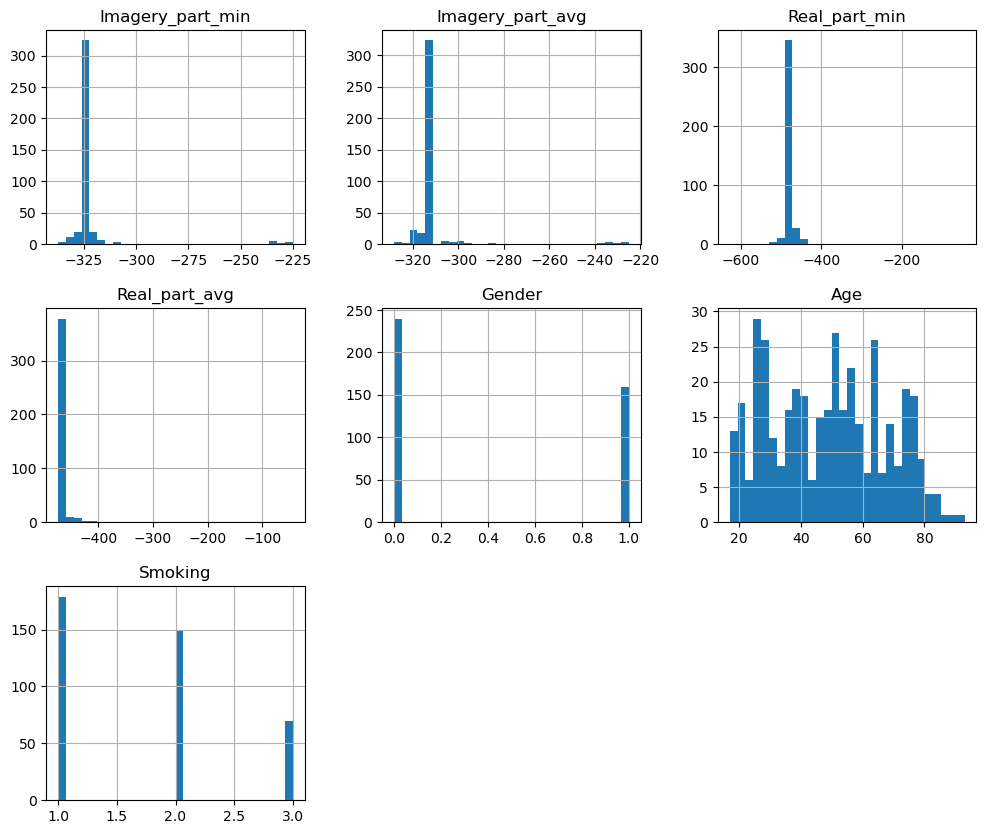

In [17]:
data.hist(figsize=(12, 10), bins=30)
plt.show()

The above code generate histograms for features.Thr output  histograms show that the Imagery and Real part features are highly skewed with most values tightly clustered and a few outliers. Gender is a binary variable but imbalanced, while Smoking is categorical with three levels, also imbalanced. Age is well distributed across a broad range, roughly uniform.

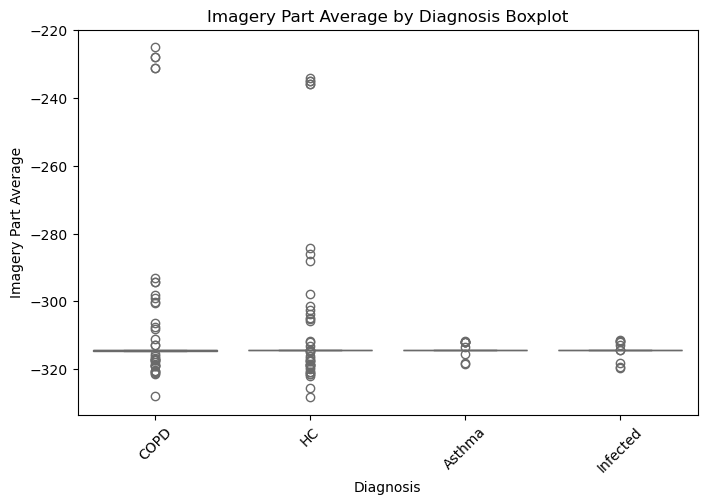

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Diagnosis', y='Imagery_part_avg', palette='Set3')
plt.title('Imagery Part Average by Diagnosis Boxplot')
plt.xlabel('Diagnosis')
plt.ylabel('Imagery Part Average')
plt.xticks(rotation=45)
plt.show()

The above code generates a boxplot visualizing the distribution of Imagery Part Average for each diagnosis group. The boxplot reveals that 'Imagery Part Average' has similar median values and data distribution across all four diagnostic groups, with noticeable outliers.

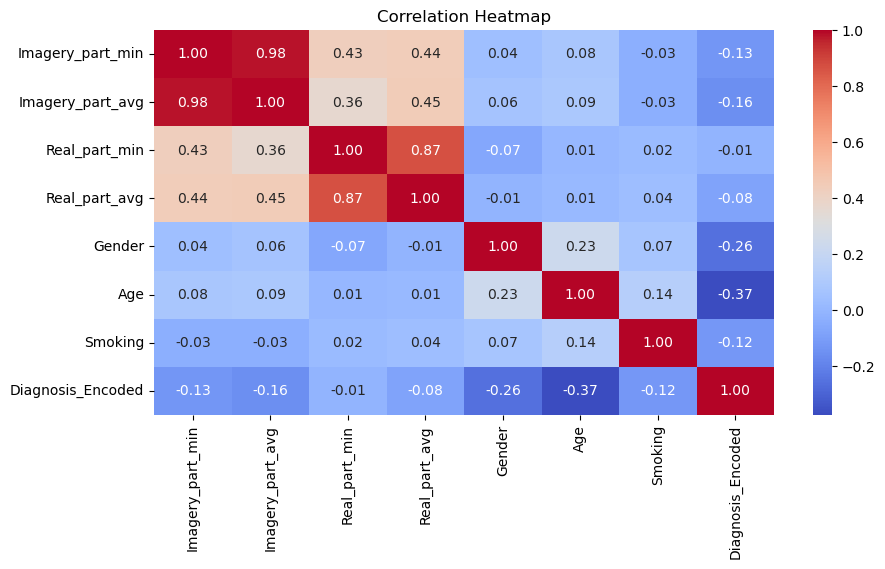

In [21]:
plt.figure(figsize=(10, 5))
# Convert 'Diagnosis' to numerical using pd.factorize before calculating correlation
data['Diagnosis_Encoded'] = pd.factorize(data['Diagnosis'])[0]
correlation_matrix = data.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The above code generates a correlation heatmap for numerical features, including the encoded 'Diagnosis', displaying the correlation coefficients between each pair of features. The heatmap reveals strong positive correlations between 'Imagery_part_min' and 'Imagery_part_avg' (0.98), and between 'Real_part_min' and 'Real_part_avg' (0.87), while showing weak correlations between 'Diagnosis_Encoded' and other features.

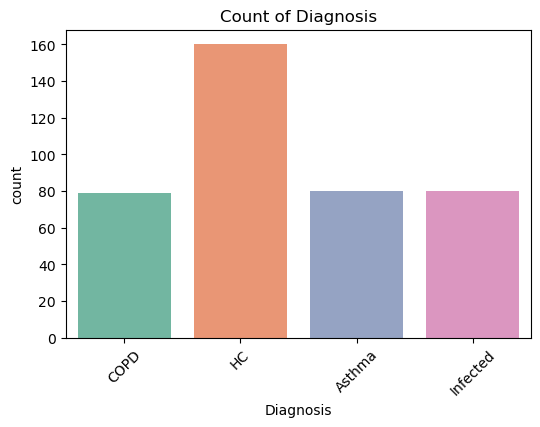

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=data,x="Diagnosis",palette="Set2")
plt.title("Count of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()

The above code generates a countplot showing the number of occurrences for each diagnosis category. The countplot reveals that the 'HC' (Healthy Control) diagnosis has the highest count, while the other three categories ('COPD', 'Asthma', 'Infected') have similar, lower counts.

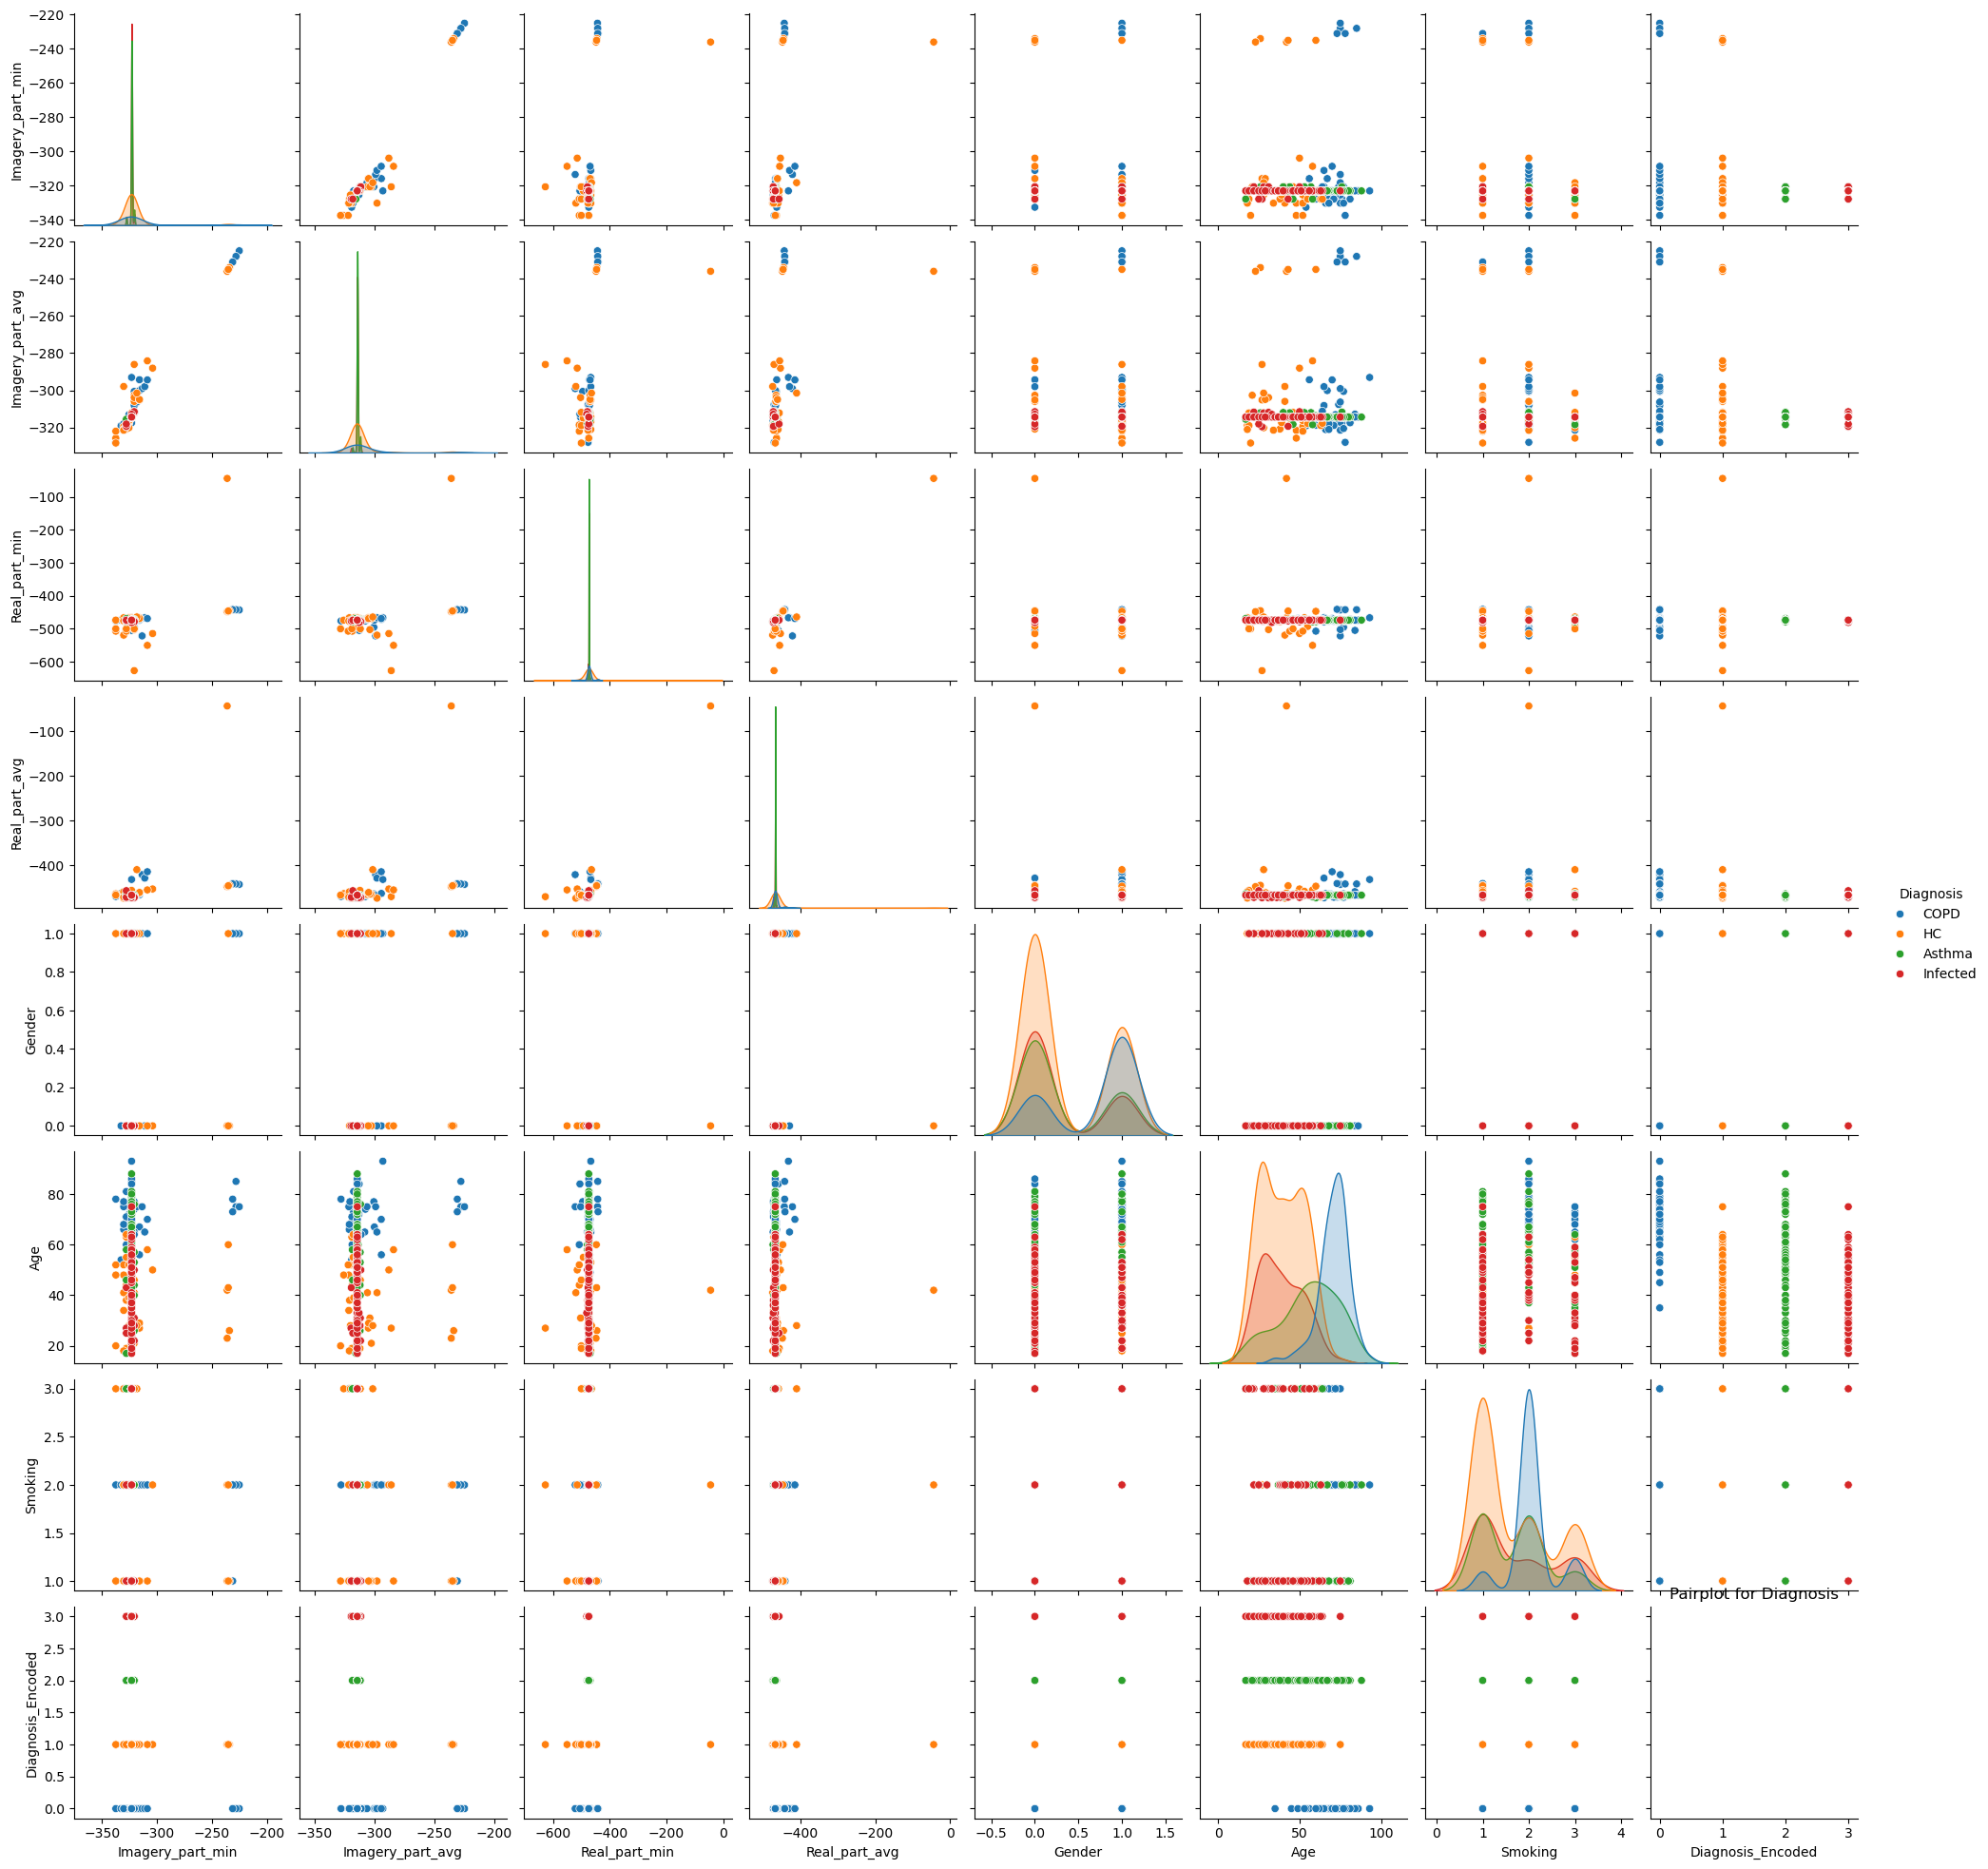

In [25]:
sns.pairplot(data,hue="Diagnosis",diag_kind="kde")
plt.title("Pairplot for Diagnosis")
plt.show()

The above code generates a pairplot displaying pairwise relationships between variables, colored by diagnosis, and reveals overlapping distributions among the diagnosis groups, with some potential correlations between variables.

In [26]:
print("\nClass Distribution Before Balancing:")
print(data['Diagnosis'].value_counts())


Class Distribution Before Balancing:
Diagnosis
HC          160
Asthma       80
Infected     80
COPD         79
Name: count, dtype: int64


The above code prints the value counts of the 'Diagnosis' column, showing the distribution of samples across each diagnosis category, and reveals an imbalanced dataset with a higher representation of the 'HC' diagnosis compared to 'Asthma', 'Infected', and 'COPD'.

In [27]:
from imblearn.combine import SMOTETomek
X = data.drop(columns=['Diagnosis', 'ID']) # Drop 'ID' column as it's not a numerical feature
y = data['Diagnosis']
smote_tomek = SMOTETomek(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
data_resampled = pd.DataFrame(X_resampled, columns=X.columns)
data_resampled['Diagnosis'] = y_resampled
# Display new class distribution after balancing
print("\nClass Distribution After Balancing:")
print(data_resampled['Diagnosis'].value_counts())


Class Distribution After Balancing:
Diagnosis
Infected    160
Asthma      159
COPD        158
HC          157
Name: count, dtype: int64


The above code uses SMOTETomek to balance the dataset by oversampling minority classes and undersampling the majority class, resulting in a more even distribution of samples across the 'Infected', 'Asthma', 'COPD', and 'HC' diagnosis categories.

**MODEL DEVELOPMENT**

**a)Loading libraries**

The code below  imports necessary libraries for model building, including scikit-learn modules for data splitting, preprocessing, Support Vector Machines (SVM), and performance evaluation metrics like accuracy, classification report, confusion matrix, 

In [31]:
!pip install -U scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**b)Feature Selection**

The  code below separates the features (all columns except 'Diagnosis') and the target variable ('Diagnosis') in the dataset into separate variables X and y, respectively, preparing the data for subsequent machine learning tasks.

In [32]:
# Separating features and target variable
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

**c)Spliting Data into Training and Testing sets**

The  code below splits the resampled data into training and testing sets (80% training, 20% testing) and sets a random state for reproducibility, preparing the data for model training and evaluation.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

**d)Standardizing**

The  code below standardizes the training and testing features by scaling them based on the mean and standard deviation of the training set, ensuring that all features have a similar range of values, which is crucial for algorithms sensitive to feature scaling. It extracts the first 7 columns of the dataset

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.values[:,:7])
X_test = scaler.transform(X_test.values[:,:7])

**e)Model Training Initializing and training the model**

The code belowtrains a Support Vector Machine (SVM) model with a radial basis function (RBF) kernel on the training data, enabling probability estimates, and sets a random state for reproducible results.

In [39]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

SVC(probability=True, random_state=42)

**MODEL EVALUATION** 

**a)Prediction**

The code below makes predictions on the test set using the trained SVM model and calculates the predicted probabilities for the positive class , storing the results in y_pred and y_prob, respectively.

In [77]:
# Predictions
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

b)**Classification Report**

The code below evaluates the performance of the SVM model by calculating the accuracy score and generating a classification report on the test set, providing insights into the model's overall correctness and its performance on each class.

In [47]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Asthma       1.00      1.00      1.00        33
        COPD       1.00      1.00      1.00        29
          HC       1.00      1.00      1.00        31
    Infected       1.00      1.00      1.00        34

    accuracy                           1.00       127
   macro avg       1.00      1.00      1.00       127
weighted avg       1.00      1.00      1.00       127



**RESULTS** -The model achieved perfect performance (100% accuracy) o. Here's a quick interpretation:

**1.Accuracy (1.0000)** – The model correctly classified all 128 cases without any errors.

**2.Precision, Recall, and F1-score (all 1.00 for each class)** – The model perfectly distinguishes between Asthma, COPD, Healthy Control (HC), and Infected cases.

**3.Support**– Each class has a reasonable number of test samples (ranging from 27 to 39), meaning the model performed well across different categories.

**4.Macro & Weighted Averages (all 1.00)**– The model performs equally well across all classes, without bias towards any particular category.

**c)Confusion Matrix**

The code below generates a confusion matrix heatmap that shows the distribution of predicted vs. actual classes, with color intensity indicating the magnitude of counts in each category

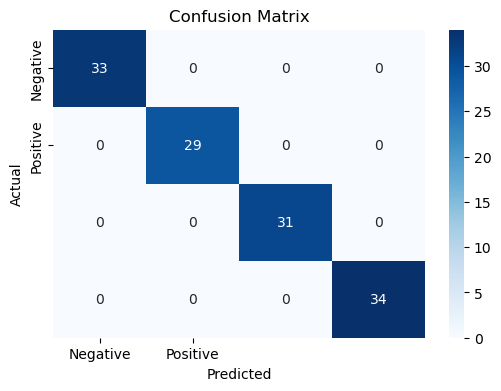

In [45]:
plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**RESULTS**-The confusion matrix confirms that the model is performing perfectly:

1.The diagonal values (39, 33, 29, and 27) indicate that all samples from each class were correctly classified.

2.There are zero misclassifications (no off-diagonal values), meaning the model never confused one class for another.

**MODEL DEPLOYMENT**

A GRAPHICAL USER INTERFACE DEPLOYMENT USING Tkinter Library

**a)Importing Libraries**
-Tkinter - for building graphical user interface (GUI).
-messagebox - for showing pop-up messages.
-Joblib - for saving and loading machine learning models efficiently.

In [41]:
import tkinter as tk
from tkinter import messagebox
import joblib
import numpy as np

**b)Saving the model and scaler**

The code below saves the trained SVM model and the scaler object to disk using joblib, allowing for later reuse of the trained model without retraining and ensuring that new data can be scaled consistently with the training data.

In [43]:
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

**c)GUI Development**

**-Function for input valiadation**

-The  code below defines a function "validate_input" that takes user inputs for features related to medical diagnoses, validates the inputs based on specific criteria, transforms the input values using a pre-fitted scaler, and predicts the diagnosis using a pre-trained SVM model. The predicted diagnosis is then displayed in a message box. Any ValueError or other exceptions raised during input validation or prediction are caught and displayed as error messages.


In [49]:
# Features used in the model 
features_to_display = ['Imagery_part_min','Imagery_part_avg',
    'Real_part_min','Real_part_avg','Gender','Age','Smoking' ]
feature_labels = {'Imagery_part_min': 'Imagery Part Minimum',
    'Imagery_part_avg': 'Imagery Part Average',
    'Real_part_min': 'Real Part Minimum',
    'Real_part_avg': 'Real Part Average',
    'Gender': 'Gender (M/F)',
    'Age': 'Age',
    'Smoking': 'Smoking Status (0/1/2)'}
input_fields = []
status_label = None
# VALIDATION FUNCTION 
def validate_input():
    try:
        status_label.config(text="Loading...", fg="blue")
        root.update_idletasks()
        input_values = []
        for i, feature in enumerate(features_to_display):
            value = input_fields[i].get()
            if 'Gender' in feature:
                if value.strip().lower() not in ['male', 'female', 'm', 'f']:
                    raise ValueError("Gender must be 'Male', 'Female', 'M', or 'F'")
                value = 1 if value.strip().lower() in ['male', 'm'] else 0
            else:
                value = float(value)
                if feature == 'Imagery_part_min' and not (-337.35 <= value <= -225.0):
                    raise ValueError("Imagery Part Minimum must be between -337.35 and -225.0")
                elif feature == 'Imagery_part_avg' and not (-328.28 <= value <= -225.0):
                    raise ValueError("Imagery Part Average must be between -328.28 and -225.0")
                elif feature == 'Real_part_min' and not (-626.86 <= value <= -44.0):
                    raise ValueError("Real Part Minimum must be between -626.86 and -44.0")
                elif feature == 'Real_part_avg' and not (-473.93 <= value <= -44.0):
                    raise ValueError("Real Part Average must be between -473.93 and -44.0")
                elif feature == 'Age' and not (1 <= value <= 120):
                    raise ValueError("Age must be between 1 and 120")
                elif feature == 'Smoking' and value not in [0, 1, 2]:
                    raise ValueError("Smoking Status must be 0, 1, or 2")
            input_values.append(value)
        input_values = np.array(input_values).reshape(1, -1)
        input_values = scaler.transform(input_values[:, :7])
        prediction = svm_model.predict(input_values)[0]
        status_label.config(text="Prediction completed", fg="green")
        messagebox.showinfo("Prediction Result", f"Predicted Diagnosis: {prediction}")
    except ValueError as e:
        status_label.config(text="", fg="red")
        messagebox.showerror("Input Error", str(e))
    except Exception as e:
        status_label.config(text="", fg="red")
        messagebox.showerror("Input Error", "Please enter valid values for all fields.")
# CLEAR FUNCTION  
def clear_fields():
    for entry in input_fields:
        entry.delete(0, tk.END)
    status_label.config(text="", fg="green")

**d)Creating the GUI window**

The  code below creates a GUI window with input fields for the features in the dataset, along with a "Predict" button that triggers the "validate_input "function when clicked. The GUI allows users to enter feature values, validate the inputs, and display the prediction from a pre-trained SVM model. It displays all columns in X.columns excluding 'ID', and 'Diagnosis_Encoded'.

In [ ]:
def create_gui():
    global root, input_fields, status_label
    root = tk.Tk()
    root.title("Respiratory Disease Predictor")
    root.geometry("450x720")
    root.configure(bg="#f2f2f2")
    tk.Label(root, text="Respiratory Disease Predictor", font=("Arial", 18, "bold"), bg="#f2f2f2").pack(pady=20)
    tk.Label(root, text="Please enter the following Patient details:", font=("Arial", 12), bg="#f2f2f2").pack(pady=5)
    input_fields.clear()
    for i, feature in enumerate(features_to_display):
        label_text = feature_labels.get(feature, feature)
        tk.Label(root, text=label_text, font=("Arial", 11), bg="#f2f2f2").pack(pady=(10, 0))
        entry = tk.Entry(root, font=("Arial", 11), width=30)
        entry.pack()
        input_fields.append(entry)
        if feature == 'Smoking':
            tk.Label(
                root,
                text="0 - Never smoked\n1 - Ex-smoker (former)\n2 - Current smoker",
                font=("Arial", 9),
                bg="#f2f2f2",
                fg="gray"
            ).pack(pady=(2, 10))
    status_label = tk.Label(root, text="", font=("Arial", 10, "italic"), bg="#f2f2f2")
    status_label.pack(pady=15)
    button_frame = tk.Frame(root, bg="#f2f2f2")
    button_frame.pack(pady=5)
    tk.Button(button_frame, text="Predict", font=("Arial", 12), bg="green", fg="white", width=15, command=validate_input).pack(side=tk.LEFT, padx=10)
    tk.Button(button_frame, text="Clear", font=("Arial", 12), bg="red", fg="white", width=15, command=clear_fields).pack(side=tk.LEFT, padx=10)
    root.mainloop()
create_gui()
